In [12]:
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

model = SentenceTransformer('all-MiniLM-L6-v2')

train_examples = [
    InputExample(texts=["query1", "relevant doc1"]),
    InputExample(texts=["query2", "relevant doc2"]),
]

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

train_loss = losses.MultipleNegativesRankingLoss(model)



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [3]:
import json

RAG_files = r"C:\Users\Luk27182\Desktop\NL2SPICE\RAG stuff\RAG_files.json"
with open(RAG_files) as f:
    RAG_data = f.read()


RAG_data = json.loads(RAG_data)

In [4]:
import glob
from sentence_transformers.util import cos_sim
from tqdm import tqdm

docs = []
doc_names = []
explainer_files = {}

for file_path in tqdm(glob.glob(r"C:\Users\Luk27182\Desktop\NL2SPICE\RAG stuff\filter_system_prompts\*.md")):
    name = file_path.split("\\")[-1].split(".")[0] # base file name
    with open(file_path) as f:
        text = f.read()
        docs.append(text)
        doc_names.append(name)
        explainer_files[name] = text

100%|██████████| 17/17 [00:00<00:00, 16989.08it/s]


In [5]:
docs_emb = model.encode(docs)

In [5]:
preds = []
correct = []

for example in tqdm(RAG_data):
    query_emb = model.encode(example["prompt"])
    scores = cos_sim(query_emb, docs_emb)[0]
    top_idx = scores.argmax()
    predicted_doc = doc_names[top_idx]
    preds.append(predicted_doc)

    truth_doc = f"{example['filter_type']}_{example['topology']}"

    if truth_doc == predicted_doc:
        correct.append(1)
    else:
        correct.append(0)

100%|██████████| 4000/4000 [00:45<00:00, 88.87it/s] 


In [6]:
print(sum(correct)/len(correct))

print(set(preds))

0.231
{'hpf_rc_single', 'notch_rc_single', 'lpf_rc_single', 'lpf_buffered_rc_single', 'hpf_buffered_rc_single', 'bpf_rc_single'}


In [ ]:
# train_examples = []

# for example in RAG_data:
#     train_examples.append(InputExample(texts=[example["prompt"],
#                                               example["explainer_content"]]))

# train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=128)

# print("dataset prepared")

100%|██████████| 4000/4000 [00:00<00:00, 999893.68it/s]


In [13]:
import random
from sentence_transformers import losses

train_examples = []

for example in RAG_data:
    truth_doc_name = f"{example['filter_type']}_{example['topology']}"

    explainer_files.keys()


    truth_doc = explainer_files[truth_doc_name]
    
    hard_neg_names = [key for key in explainer_files.keys() if example['filter_type'] in key and key != truth_doc_name]
    hard_neg_doc = explainer_files[random.choice(hard_neg_names)]
    
    ez_neg_names = [key for key in explainer_files.keys() if (not example['filter_type'] in key) and key != truth_doc_name]
    ez_neg_doc = explainer_files[random.choice(ez_neg_names)]


    train_examples.append(InputExample(texts=[example["prompt"], truth_doc, hard_neg_doc]))
    train_examples.append(InputExample(texts=[example["prompt"], truth_doc, ez_neg_doc]))

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=32)

print("dataset prepared")

train_loss = losses.TripletLoss(model)



model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=1,
    warmup_steps=200,
    optimizer_params={"lr": 5e-6}
)

dataset prepared


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\Luk27182\miniconda3\envs\pyspice_env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


KeyboardInterrupt: 

In [10]:
preds = []
correct = []

for example in tqdm(RAG_data):
    query_emb = model.encode(example["prompt"])
    scores = cos_sim(query_emb, docs_emb)[0]
    top_idx = scores.argmax()
    predicted_doc = doc_names[top_idx]
    preds.append(predicted_doc)

    truth_doc = f"{example['filter_type']}_{example['topology']}"

    if truth_doc == predicted_doc:
        correct.append(1)
    else:
        correct.append(0)

100%|██████████| 4000/4000 [01:07<00:00, 59.50it/s]


In [11]:
print(sum(correct)/len(correct))

print(set(preds))

0.1875
{'hpf_rc_single', 'lpf_buffered_rc_single', 'bpf_buffered_rc_multi', 'notch_rc_single', 'bpf_rc_single'}


In [16]:
pip install pylate

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 16.6 MB/s  0:00:00
   ---------------------------------------- 0.0/109.3 MB ? eta -:--:--
   - -------------------------------------- 3.9/109.3 MB 21.3 MB/s eta 0:00:05
   -- ------------------------------------- 7.3/109.3 MB 20.6 MB/s eta 0:00:05
   --- ------------------------------------ 10.2/109.3 MB 16.3 MB/s eta 0:00:07
   ---- ----------------------------------- 13.6/109.3 MB 16.1 MB/s eta 0:00:06
   ------ --------------------------------- 18.1/109.3 MB 17.0 MB/

  You can safely remove it manually.


In [19]:
# ── 0. Install ────────────────────────────────────────────────────────────────
# pip install pylate

import random
import numpy as np
from tqdm import tqdm
from torch.utils.data import DataLoader
from pylate import models, losses, datasets

# ── 1. Load model ─────────────────────────────────────────────────────────────
model = models.ColBERT(model_name_or_path="bert-base-uncased")

# ── 2. Evaluation function ────────────────────────────────────────────────────
def evaluate(model, RAG_data, explainer_files):
    doc_names = list(explainer_files.keys())
    doc_texts = [explainer_files[k] for k in doc_names]

    # Encode all docs with the document encoder
    docs_emb = model.encode(
        doc_texts,
        is_query=False,       # ← uses doc encoder
        show_progress_bar=True,
        convert_to_numpy=True
    )

    correct = []
    for example in tqdm(RAG_data):
        query_emb = model.encode(
            example["prompt"],
            is_query=True,    # ← uses query encoder
            convert_to_numpy=True
        )

        # MaxSim scoring (ColBERT style)
        scores = []
        for doc_emb in docs_emb:
            # query_emb: (q_len, dim), doc_emb: (d_len, dim)
            sim_matrix = np.dot(query_emb, doc_emb.T)  # (q_len, d_len)
            score = sim_matrix.max(axis=1).sum()        # MaxSim
            scores.append(score)

        top_idx = np.argmax(scores)
        predicted_doc = doc_names[top_idx]
        truth_doc = f"{example['filter_type']}_{example['topology']}"
        correct.append(int(predicted_doc == truth_doc))

    acc = sum(correct) / len(correct)
    print(f"Accuracy: {acc:.2%}  ({sum(correct)}/{len(correct)})")
    return acc

# ── 3. Baseline accuracy ──────────────────────────────────────────────────────
print("=== BEFORE TRAINING ===")
acc_before = evaluate(model, RAG_data, explainer_files)

# ── 4. Build triplet dataset ──────────────────────────────────────────────────
def build_examples(RAG_data, explainer_files):
    """Returns pylate-compatible triplet list: [query, pos, neg]"""
    examples = []
    for example in RAG_data:
        truth_doc_name = f"{example['filter_type']}_{example['topology']}"
        truth_doc = explainer_files[truth_doc_name]

        hard_neg_names = [
            k for k in explainer_files
            if example["filter_type"] in k and k != truth_doc_name
        ]
        ez_neg_names = [
            k for k in explainer_files
            if example["filter_type"] not in k and k != truth_doc_name
        ]

        hard_neg_doc = explainer_files[random.choice(hard_neg_names)]
        ez_neg_doc   = explainer_files[random.choice(ez_neg_names)]

        examples.append({
            "query":    example["prompt"],
            "positive": truth_doc,
            "negative": hard_neg_doc,
        })
        examples.append({
            "query":    example["prompt"],
            "positive": truth_doc,
            "negative": ez_neg_doc,
        })
    return examples

# ── 5. Train ──────────────────────────────────────────────────────────────────
train_loss = losses.Contrastive(model=model)

for epoch in range(5):
    print(f"\n=== Epoch {epoch+1}/5 ===")

    # Re-sample negatives each epoch
    raw_examples = build_examples(RAG_data, explainer_files)

    train_dataset = datasets.ContrastiveDataset(
        examples=raw_examples,
        model=model,
    )

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        collate_fn=train_dataset.collate_fn,
    )

    model.fit(
        train_objectives=[(train_dataloader, train_loss)],
        epochs=1,
        warmup_steps=100,
        optimizer_params={"lr": 1e-6},
    )

# ── 6. Post-training accuracy ─────────────────────────────────────────────────
print("\n=== AFTER TRAINING ===")
acc_after = evaluate(model, RAG_data, explainer_files)

print(f"\nΔ Accuracy: {acc_after - acc_before:+.2%}")

ImportError: cannot import name 'datasets' from 'pylate' (c:\Users\Luk27182\miniconda3\envs\pyspice_env\Lib\site-packages\pylate\__init__.py)

In [20]:
dir(pylate)

NameError: name 'pylate' is not defined

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Found 108 categories (first 6 words):
  [ 39]  a band-pass filter is needed with
  [ 47]  a band-pass filter is required for
  [ 22]  a band-pass filter is required to
  [ 23]  a band-pass network is required to
  [ 36]  a band-pass rc filter is required
  [ 19]  a dc-blocking filter is required for
  [ 51]  a high-pass filter is needed with
  [ 23]  a high-pass filter is required for
  [ 30]  a high-pass network is required to
  [ 21]  a high-pass rc filter is required
  [ 57]  a low-pass filter is needed with
  [ 20]  a low-pass filter is required for
  [ 20]  a low-pass network is required to
  [ 25]  a multi-stage band-pass network is required
  [ 21]  a multi-stage high-pass network is required
  [ 31]  a multi-stage low-pass network is required
  [ 18]  a multi-stage notch network is required
  [ 49]  a notch filter is needed with
  [ 58]  a notch filter is required for
  [ 33]  a notch filter is required to
  [ 28]  a notch network is required to
  [ 29]  a notch rc filter is re

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 3193/3193 [00:33<00:00, 94.66it/s] 

...

100%|██████████| 3193/3193 [00:30<00:00, 105.15it/s]

Accuracy: 100.00%  (3193/3193)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 807/807 [00:07<00:00, 103.73it/s]


Accuracy: 99.13%  (800/807)

Δ Train Accuracy: +75.45%
Δ Test  Accuracy: +81.78%


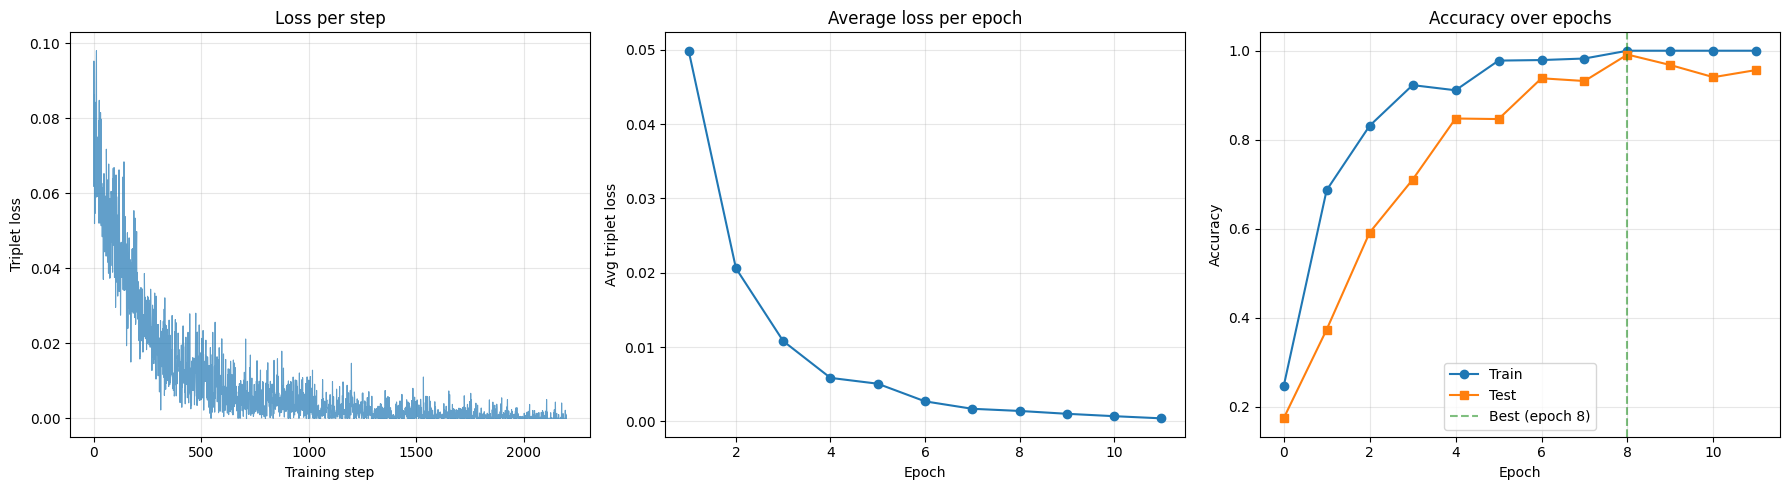

Saved: training_curves.png


In [33]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from sentence_transformers import SentenceTransformer
from torch.optim import AdamW
import torch
import torch.nn.functional as F
import copy

# ── 1. Load two separate models ───────────────────────────────────────────────
query_model = SentenceTransformer("all-MiniLM-L6-v2")
doc_model   = SentenceTransformer("all-MiniLM-L6-v2")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
query_model = query_model.to(device)
doc_model   = doc_model.to(device)

# ── 2. Forward pass that keeps gradients ──────────────────────────────────────
def encode_with_grad(model, texts):
    features = model.tokenize(texts)
    features = {k: v.to(device) for k, v in features.items() if isinstance(v, torch.Tensor)}
    out = model(features)
    embeddings = out["sentence_embedding"]
    return F.normalize(embeddings, dim=1)

# ── 3. Dataset builder ────────────────────────────────────────────────────────
def build_examples(RAG_data, explainer_files):
    examples = []
    for example in RAG_data:
        truth_doc_name = f"{example['filter_type']}_{example['topology']}"
        truth_doc = explainer_files[truth_doc_name]

        hard_neg_names = [k for k in explainer_files if example["filter_type"] in k and k != truth_doc_name]
        ez_neg_names   = [k for k in explainer_files if example["filter_type"] not in k and k != truth_doc_name]

        hard_neg_doc = explainer_files[random.choice(hard_neg_names)]
        ez_neg_doc   = explainer_files[random.choice(ez_neg_names)]

        examples.append({"query": example["prompt"], "positive": truth_doc, "negative": hard_neg_doc})
        examples.append({"query": example["prompt"], "positive": truth_doc, "negative": ez_neg_doc})
    return examples

class TripletDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples
    def __len__(self):
        return len(self.examples)
    def __getitem__(self, idx):
        return self.examples[idx]

def collate_fn(batch):
    return (
        [b["query"]    for b in batch],
        [b["positive"] for b in batch],
        [b["negative"] for b in batch],
    )

# ── 4. Train/test split by query prefix ───────────────────────────────────────
def get_category(prompt, n_words=6):
    """Category = first n words of the prompt, lowercased."""
    return " ".join(prompt.split()[:n_words]).lower()

def train_test_split_by_category(RAG_data, test_frac=0.10, seed=42, n_words=6):
    # 1. Group queries by their first-n-words category
    categories = {}
    for example in RAG_data:
        cat = get_category(example["prompt"], n_words=n_words)
        categories.setdefault(cat, []).append(example)

    # Print all categories
    print(f"Found {len(categories)} categories (first {n_words} words):")
    for cat, items in sorted(categories.items()):
        print(f"  [{len(items):3d}]  {cat}")

    # 2. Pick 10% of categories for the test set
    rng = random.Random(seed)
    cat_names = sorted(categories.keys())
    rng.shuffle(cat_names)

    n_test_cats = max(1, int(round(len(cat_names) * test_frac)))
    test_cats   = set(cat_names[:n_test_cats])
    train_cats  = set(cat_names[n_test_cats:])

    train_data = [ex for cat in train_cats for ex in categories[cat]]
    test_data  = [ex for cat in test_cats  for ex in categories[cat]]

    print(f"\nTest categories ({len(test_cats)}):")
    for cat in sorted(test_cats):
        print(f"  [{len(categories[cat]):3d}]  {cat}")

    print(f"\nTrain: {len(train_data)} examples across {len(train_cats)} categories")
    print(f"Test:  {len(test_data)} examples across {len(test_cats)} categories")

    return train_data, test_data

# ── 5. Evaluation ─────────────────────────────────────────────────────────────
def evaluate(query_model, doc_model, RAG_data, explainer_files, verbose=True):
    query_model.eval()
    doc_model.eval()

    doc_names = list(explainer_files.keys())
    doc_texts = [explainer_files[k] for k in doc_names]

    with torch.no_grad():
        docs_emb = doc_model.encode(doc_texts, show_progress_bar=verbose, convert_to_numpy=True)
        docs_emb = docs_emb / np.linalg.norm(docs_emb, axis=1, keepdims=True)

    correct = []
    iterator = tqdm(RAG_data) if verbose else RAG_data
    for example in iterator:
        with torch.no_grad():
            query_emb = query_model.encode(example["prompt"], convert_to_numpy=True)
            query_emb = query_emb / np.linalg.norm(query_emb)

        scores = docs_emb @ query_emb
        top_idx = np.argmax(scores)
        predicted_doc = doc_names[top_idx]
        truth_doc = f"{example['filter_type']}_{example['topology']}"
        correct.append(int(predicted_doc == truth_doc))

    acc = sum(correct) / len(correct)
    if verbose:
        print(f"Accuracy: {acc:.2%}  ({sum(correct)}/{len(correct)})")
    return acc

# ── 6. Triplet loss ───────────────────────────────────────────────────────────
def triplet_loss(q_emb, pos_emb, neg_emb, margin=0.1):
    pos_sim = (q_emb * pos_emb).sum(dim=1)
    neg_sim = (q_emb * neg_emb).sum(dim=1)
    return F.relu(margin - pos_sim + neg_sim).mean()

# ── 7. Split data ─────────────────────────────────────────────────────────────
train_data, test_data = train_test_split_by_category(RAG_data, test_frac=0.2, seed=42)
print(f"Train: {len(train_data)}  Test: {len(test_data)}")

# ── 8. Baseline ───────────────────────────────────────────────────────────────
print("=== BEFORE TRAINING ===")
train_acc_before = evaluate(query_model, doc_model, train_data, explainer_files)
test_acc_before  = evaluate(query_model, doc_model, test_data,  explainer_files)

# ── 9. Train with early stopping ──────────────────────────────────────────────
optimizer = AdamW(
    list(query_model.parameters()) + list(doc_model.parameters()),
    lr=1e-6
)

# History trackers
step_losses      = []   # loss at every training step
epoch_avg_losses = []   # mean loss per epoch
train_accs       = [train_acc_before]
test_accs        = [test_acc_before]

# Early stopping config
MAX_EPOCHS = 30
PATIENCE   = 3   # stop if test acc doesn't improve for this many epochs

best_test_acc = test_acc_before
best_epoch    = 0
epochs_no_improve = 0
best_query_state = copy.deepcopy(query_model.state_dict())
best_doc_state   = copy.deepcopy(doc_model.state_dict())

for epoch in range(MAX_EPOCHS):
    print(f"\n=== Epoch {epoch+1}/{MAX_EPOCHS} ===")

    query_model.train()
    doc_model.train()

    raw_examples = build_examples(train_data, explainer_files)
    dataloader   = DataLoader(
        TripletDataset(raw_examples),
        batch_size=32,
        shuffle=True,
        collate_fn=collate_fn,
    )

    total_loss = 0
    for queries, positives, negatives in tqdm(dataloader):
        q_emb   = encode_with_grad(query_model, queries)
        pos_emb = encode_with_grad(doc_model,   positives)
        neg_emb = encode_with_grad(doc_model,   negatives)

        loss = triplet_loss(q_emb, pos_emb, neg_emb, margin=0.1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        step_losses.append(loss.item())
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    epoch_avg_losses.append(avg_loss)
    print(f"Avg loss: {avg_loss:.4f}")

    # Evaluate on train and test
    train_acc = evaluate(query_model, doc_model, train_data, explainer_files, verbose=False)
    test_acc  = evaluate(query_model, doc_model, test_data,  explainer_files, verbose=False)
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    print(f"Train acc: {train_acc:.2%}  |  Test acc: {test_acc:.2%}")

    # Early stopping check
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch    = epoch + 1
        epochs_no_improve = 0
        best_query_state = copy.deepcopy(query_model.state_dict())
        best_doc_state   = copy.deepcopy(doc_model.state_dict())
        print(f"  ✓ New best test acc: {best_test_acc:.2%}")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{PATIENCE} epochs")
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}. Best was epoch {best_epoch}.")
            break

# Restore best weights
query_model.load_state_dict(best_query_state)
doc_model.load_state_dict(best_doc_state)

# ── 10. Save loss history to disk ─────────────────────────────────────────────
np.save("step_losses.npy",      np.array(step_losses))
np.save("epoch_avg_losses.npy", np.array(epoch_avg_losses))
np.save("train_accs.npy",       np.array(train_accs))
np.save("test_accs.npy",        np.array(test_accs))
print("\nSaved: step_losses.npy, epoch_avg_losses.npy, train_accs.npy, test_accs.npy")

# ── 11. Final eval with best weights ──────────────────────────────────────────
print("\n=== AFTER TRAINING (best weights restored) ===")
train_acc_after = evaluate(query_model, doc_model, train_data, explainer_files)
test_acc_after  = evaluate(query_model, doc_model, test_data,  explainer_files)
print(f"\nΔ Train Accuracy: {train_acc_after - train_acc_before:+.2%}")
print(f"Δ Test  Accuracy: {test_acc_after  - test_acc_before:+.2%}")

# ── 12. Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per-step loss
axes[0].plot(step_losses, linewidth=0.8, alpha=0.7)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Triplet loss")
axes[0].set_title("Loss per step")
axes[0].grid(alpha=0.3)

# Per-epoch avg loss
axes[1].plot(range(1, len(epoch_avg_losses) + 1), epoch_avg_losses, marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Avg triplet loss")
axes[1].set_title("Average loss per epoch")
axes[1].grid(alpha=0.3)

# Accuracy curves (epoch 0 = before training)
epochs_axis = range(len(train_accs))
axes[2].plot(epochs_axis, train_accs, marker="o", label="Train")
axes[2].plot(epochs_axis, test_accs,  marker="s", label="Test")
axes[2].axvline(best_epoch, color="green", linestyle="--", alpha=0.5, label=f"Best (epoch {best_epoch})")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_title("Accuracy over epochs")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved: training_curves.png")

In [57]:
# # Save
query_model.load_state_dict(best_query_state)
doc_model.load_state_dict(best_doc_state)
query_model.save("best_query_model")
doc_model.save("best_doc_model")

# # Reload
query_model = SentenceTransformer("best_query_model")
doc_model   = SentenceTransformer("best_doc_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [58]:
acc_after = evaluate(query_model, doc_model, RAG_data, explainer_files)
print(acc_after)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [00:33<00:00, 118.38it/s]

Accuracy: 99.83%  (3993/4000)
0.99825


In [59]:
def run_custom(query_model, doc_model, prompt, explainer_files, verbose=True):
    query_model.eval()
    doc_model.eval()

    doc_names = list(explainer_files.keys())
    doc_texts = [explainer_files[k] for k in doc_names]

    with torch.no_grad():
        docs_emb = doc_model.encode(doc_texts, show_progress_bar=verbose, convert_to_numpy=True)
        docs_emb = docs_emb / np.linalg.norm(docs_emb, axis=1, keepdims=True)

    with torch.no_grad():
        query_emb = query_model.encode(prompt, convert_to_numpy=True)
        query_emb = query_emb / np.linalg.norm(query_emb)

        scores = docs_emb @ query_emb
        top_idx = np.argmax(scores)
        predicted_doc = doc_names[top_idx]

    return predicted_doc

In [65]:
prompt = "Make a low pass RC filter with as few parts as possible"
prompt = "A weakly driven source with a large and fluctuating output impedance requires strong bandpass filtering to extract a tight frequency band of interest. The desired passband extends from fc_low to fc_high and should not exceed a loss of pb dB. Outside this region, achieve at least atten dB attenuation at both fs_low and fs_high. Design the RC stage so it is driven by a low-impedance source to maintain a stable, predictable response, while minimizing the number of components used."
# prompt = ""


run_custom(query_model, doc_model, prompt, explainer_files, verbose=False)

'lpf_buffered_rc_multi'